<a href="https://colab.research.google.com/github/doanthuchuyen/thuchuyen07.github.io/blob/gh-pages/BT03_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
iris_data = load_iris(as_frame=True)
df_data = iris_data.frame

In [9]:
new_columns = {
    'sepal length (cm)': 'sepal_length',
    'sepal width (cm)': 'sepal_width',
    'petal length (cm)': 'petal_length',
    'petal width (cm)': 'petal_width',
    'target': 'species_code'
}
df_data.rename(columns=new_columns, inplace=True)
species_map = {0: 'Iris-Setosa', 1: 'Iris-Versicolor', 2: 'Iris-Virginica'}
df_data['Species_Name'] = df_data['species_code'].map(species_map)

In [10]:
print("5 dòng đầu tiên của DataFrame đã được chuẩn bị:")
display(df_data.head())
print("\nThông tin về dữ liệu:")
df_data.info()

5 dòng đầu tiên của DataFrame đã được chuẩn bị:


,sepal_length,sepal_width,petal_length,petal_width,species_code,Species_Name
0,5.1,3.5,1.4,0.2,0,Iris-Setosa
1,4.9,3.0,1.4,0.2,0,Iris-Setosa
2,4.7,3.2,1.3,0.2,0,Iris-Setosa
3,4.6,3.1,1.5,0.2,0,Iris-Setosa
4,5.0,3.6,1.4,0.2,0,Iris-Setosa



Thông tin về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species_code  150 non-null    int64  
 5   Species_Name  150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [11]:
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

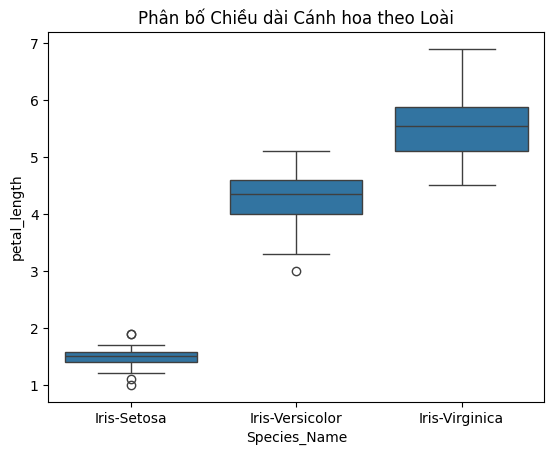

In [12]:
sns.boxplot(x='Species_Name', y='petal_length', data=df_data)
plt.title('Phân bố Chiều dài Cánh hoa theo Loài')
plt.show()

In [13]:
X = df_data[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df_data['species_code']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=88)

In [15]:
dt_model = DecisionTreeClassifier(max_depth=3, random_state=88)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=88)

In [16]:
y_pred = dt_model.predict(X_test)
print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH DECISION TREE ---")
print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\nMa trận nhầm lẫn (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred))


--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH DECISION TREE ---
Độ chính xác (Accuracy): 0.9211

Ma trận nhầm lẫn (Confusion Matrix):
[[13  0  0]
 [ 0 10  0]
 [ 0  3 12]]


In [17]:
target_names = list(species_map.values())
print("\nBáo cáo phân loại (Classification Report):\n")
print(classification_report(y_test, y_pred, target_names=target_names))


Báo cáo phân loại (Classification Report):

                 precision    recall  f1-score   support

    Iris-Setosa       1.00      1.00      1.00        13
Iris-Versicolor       0.77      1.00      0.87        10
 Iris-Virginica       1.00      0.80      0.89        15

       accuracy                           0.92        38
      macro avg       0.92      0.93      0.92        38
   weighted avg       0.94      0.92      0.92        38



In [18]:
save_dir = '.'
joblib.dump(dt_model, f'{save_dir}/iris_dt_model.joblib')
print(f"\nMô hình Decision Tree đã được lưu thành: iris_dt_model.joblib")


Mô hình Decision Tree đã được lưu thành: iris_dt_model.joblib
